In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

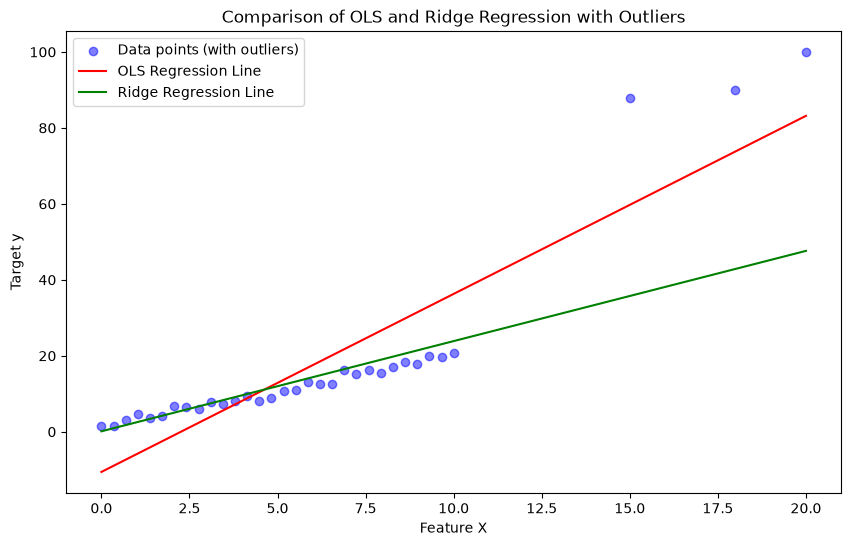

In [2]:
# Generate a simple linear dataset
n_samples = 30
X_input = np.linspace(0, 10, n_samples)
y = 2 * X_input + 1 + np.random.randn(n_samples)  # True slope = 2, intercept = 1, with noise

# Add 3 outliers to the dataset
X_input = np.append(X_input, [15, 18, 20]) # Farther on the X-axis
y = np.append(y, [88, 90, 100]) # Much higher on the Y-axis

# Add the intercept term
X = np.hstack((np.ones((n_samples + 3, 1)), X_input.reshape(-1, 1)))

# Create the OLS and Ridge regression models
beta_OLS = np.linalg.inv(X.T @ X) @ X.T @ y  # Ordinary Least Squares
lambda_ridge = 1000  # Regularization parameter for Ridge regression
I = np.eye(X.shape[1])  # Identity matrix
beta_ridge = np.linalg.inv(X.T @ X + lambda_ridge * I) @ X.T @ y  # Ridge regression

# Prepare to Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_input, y, color='blue', alpha=0.5, label='Data points (with outliers)')

# Plot OLS fit
x_range = np.linspace(np.min(X_input), np.max(X_input), 100)
y_OLS = beta_OLS[0] + beta_OLS[1] * x_range
plt.plot(x_range, y_OLS, color='red', label='OLS Regression Line')

# Plot Ridge fit
y_ridge = beta_ridge[0] + beta_ridge[1] * x_range
plt.plot(x_range, y_ridge, color='green', label='Ridge Regression Line')

plt.title('Comparison of OLS and Ridge Regression with Outliers')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.show()